In [13]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/gmschen
/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta
/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026
/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/notebooks
/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/src
/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/data
/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/data/processed
/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/data/embeddings
/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/data/raw


In [14]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026')
sys.path.insert(0, str(PROJECT_ROOT))

# /kaggle/input es solo lectura -> resultados van a /kaggle/working
RESULTS_DIR = Path('/kaggle/working/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

from src.dataset import (
    PAD_IDX, UNK_IDX,
    build_vocabulary,
    load_glove,
    FakeNewsDataset,
    create_dataloaders,
)
from src.model import TextCNN
from src.train import train_model
from src.evaluate import evaluate_model, get_predictions, plot_confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Dispositivo : {device}')
print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')

Dispositivo : cuda
PyTorch     : 2.10.0+cu128
CUDA        : True


In [15]:
clean_path = PROJECT_ROOT / 'data' / 'processed' / 'wellfake_clean.csv'
raw_path   = PROJECT_ROOT / 'data' / 'raw' / 'WELFake_Dataset.csv'

if clean_path.exists():
    df = pd.read_csv(clean_path)
    print(f'Datos limpios cargados: {clean_path}')
else:
    df = pd.read_csv(raw_path)
    df = df.dropna(subset=['text', 'label'])
    df['title'] = df['title'].fillna('')
    df['text']  = df['text'].astype(str).str.lower().str.strip()
    print(f'Datos originales cargados: {raw_path}')

if 'title' not in df.columns:
    df['title'] = ''
df['title'] = df['title'].fillna('').astype(str)
df['text']  = df['text'].fillna('').astype(str)

# Campo combinado por defecto para los sweeps de LR/filtros/dropout
df['text_combined'] = (df['title'] + ' ' + df['text']).str.strip()

print(f'Forma del DataFrame: {df.shape}')
print(df['label'].value_counts())

Datos limpios cargados: /kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/data/processed/wellfake_clean.csv
Forma del DataFrame: (61394, 6)
label
0    34237
1    27157
Name: count, dtype: int64


In [16]:
!pip install contractions -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 5.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00


In [17]:
import re, unicodedata, contractions, spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
POS_KEEP = {'NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV'}

def clean_text(text: str) -> str:
    # P1: Contracciones (ANTES de quitar signos)
    try:
        text = contractions.fix(text)
    except IndexError:
        pass
    text = text.lower()

    # P2: Lematización + filtro POS
    doc = nlp(text)
    tokens = [
        t.lemma_ for t in doc
        if t.pos_ in POS_KEEP
        and not t.is_space
        and len(t.lemma_) > 1
    ]
    text = " ".join(tokens)

    # P3: Signos residuales + cirílico (AL FINAL)
    text = re.sub(r'http\S+|www\.\S+', '', text) # URLs
    text = re.sub(r'[@#]\w+', '', text) # menciones/hashtags
    text = re.sub(r'[\u0400-\u04FF]+', '', text) # caracteres cirílicos (ruso)
    text = re.sub(r'[^\w\s]', ' ', text) # puntuación residual
    text = re.sub(r'\b\d+\b', '', text) # dígitos aislados
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df.columns

def fix_contractions(text):
    try:
        return contractions.fix(text)
    except IndexError:
        return text

def limpiar_signos(text):
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'[\u0400-\u04FF]+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def aplicar_pipeline(serie):
    """Aplica P1→P2→P3 a una Series de texto."""
    pre = [fix_contractions(t).lower() for t in serie.astype(str)]
    limpios = []
    for doc in nlp.pipe(pre, batch_size=512):
        tokens = [t.lemma_ for t in doc if t.pos_ in POS_KEEP and not t.is_space and len(t.lemma_) > 1]
        limpios.append(" ".join(tokens))
    return [limpiar_signos(t) for t in limpios]

print("Limpiando text...")
df['text'] = aplicar_pipeline(df['text'])
print("Limpiando title...")
df['title'] = aplicar_pipeline(df['title'])

# Combinar title + text en una sola columna
df['text_combined'] = df['title'] + ' ' + df['text']

print("Limpieza completa")
print(f"Ejemplo text    : {df['text'].iloc[0][:80]}")
print(f"Ejemplo title   : {df['title'].iloc[0][:80]}")
print(f"Ejemplo combined: {df['text_combined'].iloc[0][:80]}")

Limpiando text...
Limpiando title...
Limpieza completa
Ejemplo text    : comment expect barack obama member fyf911 fukyoflag blacklivesmatt movement call
Ejemplo title   : law enforcement high alert follow threat cop white 11by blacklivesmatter fyf911 
Ejemplo combined: law enforcement high alert follow threat cop white 11by blacklivesmatter fyf911 


In [18]:
# Split 80/10/10 estratificado (mismo que Reto 3 y 4)
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

train_labels = train_df['label'].tolist()
val_labels   = val_df['label'].tolist()
test_labels  = test_df['label'].tolist()

# Texto base: title+text combinado (se usa en sweeps 1, 2 y 3)
train_texts = train_df['text_combined'].tolist()
val_texts   = val_df['text_combined'].tolist()
test_texts  = test_df['text_combined'].tolist()

MAX_VOCAB = 20_000
MAX_LEN   = 200
BATCH_SIZE = 64
EMBED_DIM  = 50

word2idx   = build_vocabulary(train_texts, max_vocab=MAX_VOCAB)
VOCAB_SIZE = len(word2idx)
print(f'Vocabulario: {VOCAB_SIZE:,} tokens')

train_loader, val_loader, test_loader = create_dataloaders(
    train_data=(train_texts, train_labels),
    val_data  =(val_texts,   val_labels),
    test_data =(test_texts,  test_labels),
    word2idx  =word2idx,
    batch_size=BATCH_SIZE,
    max_len   =MAX_LEN,
)
print(f'Batches - Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Vocabulario: 20,002 tokens
DataLoaders creados:
  Entrenamiento: 49,115 muestras -> 768 batches
  Validacion:    6,139 muestras -> 96 batches
  Prueba:        6,140 muestras -> 96 batches
  Batch size: 64 | Max len: 200
Batches - Train: 768 | Val: 96 | Test: 96


In [19]:
GLOVE_PATH = PROJECT_ROOT / 'data' / 'embeddings' / 'glove.6B.50d.txt'

if GLOVE_PATH.exists():
    embedding_matrix = load_glove(str(GLOVE_PATH), word2idx, embed_dim=EMBED_DIM)
    print(f'GloVe cargado: {embedding_matrix.shape}')
else:
    print(f'GloVe no encontrado en: {GLOVE_PATH}')
    embedding_matrix = np.random.normal(scale=0.6, size=(VOCAB_SIZE, EMBED_DIM)).astype(np.float32)
    embedding_matrix[PAD_IDX] = np.zeros(EMBED_DIM)

GloVe cargado: 19,520 / 20,002 palabras encontradas (97.6% de cobertura)
GloVe cargado: (20002, 50)


In [20]:
experiments = []

def run_experiment(config, experiment_id, notes='',
                    loaders=None, vocab_size=None, emb_matrix=None):
    """Entrena un TextCNN con la config dada y guarda metricas en `experiments`.

    config keys soportadas: lr, num_filters, dropout, embed_dim, kernel_sizes
    loaders: tupla (train_loader, val_loader, test_loader); si None usa los globales
    """
    tr_loader, v_loader, te_loader = loaders if loaders else (train_loader, val_loader, test_loader)
    vsize = vocab_size if vocab_size is not None else VOCAB_SIZE
    emb   = emb_matrix if emb_matrix is not None else embedding_matrix

    torch.manual_seed(42)
    model = TextCNN(
        vocab_size=vsize,
        embed_dim=config.get('embed_dim', 100),
        num_filters=config.get('num_filters', 100),
        kernel_sizes=config.get('kernel_sizes', [3, 4, 5]),
        dropout=config.get('dropout', 0.5),
        num_classes=1,
        pretrained_embeddings=emb,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config.get('lr', 1e-3))
    criterion = nn.BCEWithLogitsLoss()

    history = train_model(
        model=model, train_loader=tr_loader, val_loader=v_loader,
        optimizer=optimizer, criterion=criterion, device=device,
        num_epochs=10, patience=3,
    )

    test_metrics = evaluate_model(model, te_loader, criterion, device)

    result = {
        'experiment_id': experiment_id,
        'config': str(config),
        'notes': notes,
        'epochs_trained': len(history['train_loss']),
        'val_f1': round(max(history['val_f1']), 4),
        'val_loss_min': round(min(history['val_loss']), 4),
        'test_f1': round(test_metrics['f1'], 4),
        'test_accuracy': round(test_metrics['accuracy'], 4),
        'test_precision': round(test_metrics['precision'], 4),
        'test_recall': round(test_metrics['recall'], 4),
        'test_loss': round(test_metrics['loss'], 4),
    }
    experiments.append(result)
    print(f"[{experiment_id}] val_f1={result['val_f1']}  test_f1={result['test_f1']}  epocas={result['epochs_trained']}")
    return model, history, result

print('Funcion run_experiment lista. Lista experiments inicializada vacia.')

Funcion run_experiment lista. Lista experiments inicializada vacia.


In [22]:
print('=== SWEEP: Learning Rate ===')
for lr in [5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5]:
    run_experiment(
        {'lr': lr, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50},
        experiment_id=f'lr_{lr}',
        notes=f'Sweep LR: lr={lr}, resto fijo (filters=100, dropout=0.5)',
    )

=== SWEEP: Learning Rate ===
Epoch 01/10 | Train Loss: 4.7005  Train F1: 0.8463 | Val Loss: 2.7746  Val F1: 0.9076
Epoch 02/10 | Train Loss: 2.9360  Train F1: 0.8938 | Val Loss: 1.5628  Val F1: 0.8910
Epoch 03/10 | Train Loss: 1.7275  Train F1: 0.8977 | Val Loss: 2.2712  Val F1: 0.8864
Epoch 04/10 | Train Loss: 1.9212  Train F1: 0.8787 | Val Loss: 3.7121  Val F1: 0.8888

Early stopping en epoca 4. Mejor Val F1: 0.9076
[lr_0.05] val_f1=0.9076  test_f1=0.9039  epocas=4
Epoch 01/10 | Train Loss: 0.1971  Train F1: 0.9126 | Val Loss: 0.1141  Val F1: 0.9474
Epoch 02/10 | Train Loss: 0.1267  Train F1: 0.9534 | Val Loss: 0.1371  Val F1: 0.9464
Epoch 03/10 | Train Loss: 0.0975  Train F1: 0.9692 | Val Loss: 0.2749  Val F1: 0.9443
Epoch 04/10 | Train Loss: 0.1167  Train F1: 0.9713 | Val Loss: 0.3203  Val F1: 0.9430

Early stopping en epoca 4. Mejor Val F1: 0.9474
[lr_0.01] val_f1=0.9474  test_f1=0.9475  epocas=4
Epoch 01/10 | Train Loss: 0.1778  Train F1: 0.9163 | Val Loss: 0.1101  Val F1: 0.9516

In [23]:
print('=== SWEEP: Num Filters ===')
for nf in [50, 100, 150, 200, 250, 300, 350, 400]:
    run_experiment(
        {'lr': 1e-3, 'num_filters': nf, 'dropout': 0.5, 'embed_dim': 50},
        experiment_id=f'filters_{nf}',
        notes=f'Sweep Filtros: num_filters={nf}, resto fijo (lr=1e-3, dropout=0.5)',
    )

=== SWEEP: Num Filters ===
Epoch 01/10 | Train Loss: 0.2564  Train F1: 0.8710 | Val Loss: 0.1524  Val F1: 0.9321
Epoch 02/10 | Train Loss: 0.1302  Train F1: 0.9436 | Val Loss: 0.1171  Val F1: 0.9458
Epoch 03/10 | Train Loss: 0.0907  Train F1: 0.9618 | Val Loss: 0.1084  Val F1: 0.9507
Epoch 04/10 | Train Loss: 0.0645  Train F1: 0.9738 | Val Loss: 0.1115  Val F1: 0.9541
Epoch 05/10 | Train Loss: 0.0451  Train F1: 0.9831 | Val Loss: 0.1148  Val F1: 0.9501
Epoch 06/10 | Train Loss: 0.0298  Train F1: 0.9891 | Val Loss: 0.1297  Val F1: 0.9488
Epoch 07/10 | Train Loss: 0.0218  Train F1: 0.9928 | Val Loss: 0.1382  Val F1: 0.9521

Early stopping en epoca 7. Mejor Val F1: 0.9541
[filters_50] val_f1=0.9541  test_f1=0.951  epocas=7
Epoch 01/10 | Train Loss: 0.2449  Train F1: 0.8761 | Val Loss: 0.1504  Val F1: 0.9346
Epoch 02/10 | Train Loss: 0.1198  Train F1: 0.9488 | Val Loss: 0.1097  Val F1: 0.9506
Epoch 03/10 | Train Loss: 0.0801  Train F1: 0.9663 | Val Loss: 0.1035  Val F1: 0.9533
Epoch 04/10 

In [25]:
print('=== SWEEP: Dropout ===')
for dp in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    run_experiment(
        {'lr': 1e-3, 'num_filters': 350, 'dropout': dp, 'embed_dim': 50},
        experiment_id=f'dropout_{dp}',
        notes=f'Sweep Dropout: dropout={dp}, resto fijo (lr=1e-3, filters=100)',
    )

=== SWEEP: Dropout ===
Epoch 01/10 | Train Loss: 0.1831  Train F1: 0.9136 | Val Loss: 0.1128  Val F1: 0.9508
Epoch 02/10 | Train Loss: 0.0708  Train F1: 0.9705 | Val Loss: 0.0994  Val F1: 0.9562
Epoch 03/10 | Train Loss: 0.0255  Train F1: 0.9922 | Val Loss: 0.0968  Val F1: 0.9577
Epoch 04/10 | Train Loss: 0.0063  Train F1: 0.9995 | Val Loss: 0.1077  Val F1: 0.9569
Epoch 05/10 | Train Loss: 0.0022  Train F1: 0.9999 | Val Loss: 0.1186  Val F1: 0.9589
Epoch 06/10 | Train Loss: 0.0013  Train F1: 0.9999 | Val Loss: 0.1320  Val F1: 0.9595
Epoch 07/10 | Train Loss: 0.0012  Train F1: 0.9998 | Val Loss: 0.1381  Val F1: 0.9589
Epoch 08/10 | Train Loss: 0.0087  Train F1: 0.9967 | Val Loss: 0.1802  Val F1: 0.9518
Epoch 09/10 | Train Loss: 0.0028  Train F1: 0.9988 | Val Loss: 0.1566  Val F1: 0.9584

Early stopping en epoca 9. Mejor Val F1: 0.9595
[dropout_0.0] val_f1=0.9595  test_f1=0.9617  epocas=9
Epoch 01/10 | Train Loss: 0.1895  Train F1: 0.9090 | Val Loss: 0.1162  Val F1: 0.9502
Epoch 02/10 | 

In [26]:
print('=== SWEEP: Campo de entrada ===')

campos = {
    'solo_title': (train_df['title'].tolist(), val_df['title'].tolist(), test_df['title'].tolist()),
    'solo_text':  (train_df['text'].tolist(),  val_df['text'].tolist(),  test_df['text'].tolist()),
    'title_text': (train_df['text_combined'].tolist(), val_df['text_combined'].tolist(), test_df['text_combined'].tolist()),
}

for nombre_campo, (tr_t, v_t, te_t) in campos.items():
    w2i_campo = build_vocabulary(tr_t, max_vocab=MAX_VOCAB)
    vsize_campo = len(w2i_campo)

    tr_loader_c, v_loader_c, te_loader_c = create_dataloaders(
        train_data=(tr_t, train_labels),
        val_data  =(v_t,  val_labels),
        test_data =(te_t, test_labels),
        word2idx  =w2i_campo,
        batch_size=BATCH_SIZE,
        max_len   =MAX_LEN,
    )

    if GLOVE_PATH.exists():
        emb_campo = load_glove(str(GLOVE_PATH), w2i_campo, embed_dim=EMBED_DIM)
    else:
        emb_campo = np.random.normal(scale=0.6, size=(vsize_campo, EMBED_DIM)).astype(np.float32)
        emb_campo[PAD_IDX] = np.zeros(EMBED_DIM)

    run_experiment(
        {'lr': 1e-3, 'num_filters': 300, 'dropout': 0.0, 'embed_dim': 50},
        experiment_id=f'campo_{nombre_campo}',
        notes=f'Sweep Campo de entrada: {nombre_campo}, vocab={vsize_campo}',
        loaders=(tr_loader_c, v_loader_c, te_loader_c),
        vocab_size=vsize_campo,
        emb_matrix=emb_campo,
    )

=== SWEEP: Campo de entrada ===
DataLoaders creados:
  Entrenamiento: 49,115 muestras -> 768 batches
  Validacion:    6,139 muestras -> 96 batches
  Prueba:        6,140 muestras -> 96 batches
  Batch size: 64 | Max len: 200
GloVe cargado: 18,209 / 20,002 palabras encontradas (91.0% de cobertura)
Epoch 01/10 | Train Loss: 0.3533  Train F1: 0.8146 | Val Loss: 0.2797  Val F1: 0.8680
Epoch 02/10 | Train Loss: 0.2410  Train F1: 0.8852 | Val Loss: 0.2518  Val F1: 0.8846
Epoch 03/10 | Train Loss: 0.1907  Train F1: 0.9131 | Val Loss: 0.2538  Val F1: 0.8781
Epoch 04/10 | Train Loss: 0.1536  Train F1: 0.9305 | Val Loss: 0.2648  Val F1: 0.8861
Epoch 05/10 | Train Loss: 0.1230  Train F1: 0.9460 | Val Loss: 0.2891  Val F1: 0.8863
Epoch 06/10 | Train Loss: 0.1010  Train F1: 0.9560 | Val Loss: 0.3154  Val F1: 0.8869
Epoch 07/10 | Train Loss: 0.0837  Train F1: 0.9648 | Val Loss: 0.3515  Val F1: 0.8802
Epoch 08/10 | Train Loss: 0.0680  Train F1: 0.9718 | Val Loss: 0.3908  Val F1: 0.8857
Epoch 09/10 | 

In [27]:
exp_df = pd.DataFrame(experiments)

print('=' * 90)
print('TABLA DE EXPERIMENTOS')
print('=' * 90)
print(exp_df.to_string(index=False))

out_csv = RESULTS_DIR / 'experiments.csv'
exp_df.to_csv(out_csv, index=False)
print(f'\nGuardado en: {out_csv}')

TABLA DE EXPERIMENTOS
   experiment_id                                                              config                                                             notes  epochs_trained  val_f1  val_loss_min  test_f1  test_accuracy  test_precision  test_recall  test_loss
         lr_0.05   {'lr': 0.05, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50}          Sweep LR: lr=0.05, resto fijo (filters=100, dropout=0.5)               4  0.9076        1.5628   0.9039         0.9135          0.8887       0.9197     3.3060
         lr_0.01   {'lr': 0.01, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50}          Sweep LR: lr=0.01, resto fijo (filters=100, dropout=0.5)               4  0.9474        0.1141   0.9475         0.9533          0.9412       0.9540     0.1256
        lr_0.005  {'lr': 0.005, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50}         Sweep LR: lr=0.005, resto fijo (filters=100, dropout=0.5)               5  0.9551        0.1005   0.9548         0.9601       

In [28]:
best_exp = exp_df.loc[exp_df['val_f1'].idxmax()]

print('=== MEJOR EXPERIMENTO ===')
print(f"ID         : {best_exp['experiment_id']}")
print(f"Config     : {best_exp['config']}")
print(f"Notas      : {best_exp['notes']}")
print(f"Val F1     : {best_exp['val_f1']}")
print(f"Test F1    : {best_exp['test_f1']}")
print(f"Test Acc   : {best_exp['test_accuracy']}")
print(f"Epocas     : {best_exp['epochs_trained']}")

=== MEJOR EXPERIMENTO ===
ID         : dropout_0.0
Config     : {'lr': 0.001, 'num_filters': 350, 'dropout': 0.0, 'embed_dim': 50}
Notas      : Sweep Dropout: dropout=0.0, resto fijo (lr=1e-3, filters=100)
Val F1     : 0.9595
Test F1    : 0.9617
Test Acc   : 0.9658
Epocas     : 9


Epoch 01/10 | Train Loss: 0.1830  Train F1: 0.9138 | Val Loss: 0.1127  Val F1: 0.9508
Epoch 02/10 | Train Loss: 0.0704  Train F1: 0.9707 | Val Loss: 0.0997  Val F1: 0.9572
Epoch 03/10 | Train Loss: 0.0256  Train F1: 0.9921 | Val Loss: 0.0975  Val F1: 0.9550
Epoch 04/10 | Train Loss: 0.0064  Train F1: 0.9994 | Val Loss: 0.1093  Val F1: 0.9579
Epoch 05/10 | Train Loss: 0.0022  Train F1: 0.9999 | Val Loss: 0.1187  Val F1: 0.9599
Epoch 06/10 | Train Loss: 0.0012  Train F1: 1.0000 | Val Loss: 0.1308  Val F1: 0.9587
Epoch 07/10 | Train Loss: 0.0009  Train F1: 0.9999 | Val Loss: 0.1394  Val F1: 0.9568
Epoch 08/10 | Train Loss: 0.0040  Train F1: 0.9987 | Val Loss: 0.2151  Val F1: 0.9558

Early stopping en epoca 8. Mejor Val F1: 0.9599
[mejor_reentrenado] val_f1=0.9599  test_f1=0.9621  epocas=8
Epoch 01/10 | Train Loss: 0.1830  Train F1: 0.9136 | Val Loss: 0.1132  Val F1: 0.9512
Epoch 02/10 | Train Loss: 0.0703  Train F1: 0.9711 | Val Loss: 0.0974  Val F1: 0.9582
Epoch 03/10 | Train Loss: 0.025

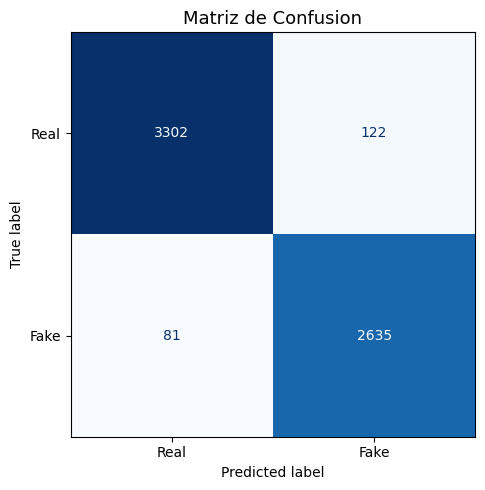

In [29]:
import ast
best_config = ast.literal_eval(best_exp['config'])

# Determinar que loaders usar segun si el mejor experimento fue del sweep de campo
if 'campo_' in best_exp['experiment_id']:
    nombre_campo_best = best_exp['experiment_id'].replace('campo_', '')
    tr_t, v_t, te_t = campos[nombre_campo_best]
    w2i_final = build_vocabulary(tr_t, max_vocab=MAX_VOCAB)
    vsize_final = len(w2i_final)
    train_loader_f, val_loader_f, test_loader_f = create_dataloaders(
        train_data=(tr_t, train_labels), val_data=(v_t, val_labels), test_data=(te_t, test_labels),
        word2idx=w2i_final, batch_size=BATCH_SIZE, max_len=MAX_LEN,
    )
    if GLOVE_PATH.exists():
        emb_final = load_glove(str(GLOVE_PATH), w2i_final, embed_dim=EMBED_DIM)
    else:
        emb_final = np.random.normal(scale=0.6, size=(vsize_final, EMBED_DIM)).astype(np.float32)
        emb_final[PAD_IDX] = np.zeros(EMBED_DIM)
    test_df_final = test_df.copy()
    test_texts_final = te_t
else:
    train_loader_f, val_loader_f, test_loader_f = train_loader, val_loader, test_loader
    vsize_final = VOCAB_SIZE
    emb_final = embedding_matrix
    test_df_final = test_df.copy()
    test_texts_final = test_texts

_, _, _ = run_experiment(
    best_config, experiment_id='mejor_reentrenado',
    notes='Reentrenamiento de la mejor config para analisis de errores',
    loaders=(train_loader_f, val_loader_f, test_loader_f),
    vocab_size=vsize_final, emb_matrix=emb_final,
)

torch.manual_seed(42)
best_model = TextCNN(
    vocab_size=vsize_final, embed_dim=best_config.get('embed_dim', 100),
    num_filters=best_config.get('num_filters', 100),
    kernel_sizes=best_config.get('kernel_sizes', [3, 4, 5]),
    dropout=best_config.get('dropout', 0.5),
    pretrained_embeddings=emb_final,
).to(device)
best_opt = torch.optim.Adam(best_model.parameters(), lr=best_config.get('lr', 1e-3))
criterion = nn.BCEWithLogitsLoss()
train_model(best_model, train_loader_f, val_loader_f, best_opt, criterion, device, num_epochs=10, patience=3)

y_true, y_pred, y_proba = get_predictions(best_model, test_loader_f, device)
plot_confusion_matrix(y_true, y_pred, labels=['Real', 'Fake'])

In [30]:
import numpy as np

y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)
errores_idx = np.where(y_true_arr != y_pred_arr)[0]

print(f'Total de errores: {len(errores_idx)} / {len(y_true_arr)} ({len(errores_idx)/len(y_true_arr)*100:.1f}%)')

test_df_reset = test_df_final.reset_index(drop=True)

muestra_errores = np.random.RandomState(42).choice(errores_idx, size=min(15, len(errores_idx)), replace=False)

print('\n=== Ejemplos mal clasificados ===\n')
longitudes_error = []
direccion_error = {'Real->Fake': 0, 'Fake->Real': 0}

for idx in muestra_errores:
    real = 'Fake' if y_true_arr[idx] == 1 else 'Real'
    pred = 'Fake' if y_pred_arr[idx] == 1 else 'Real'
    texto = str(test_texts_final[idx])
    longitudes_error.append(len(texto.split()))
    if real == 'Real' and pred == 'Fake':
        direccion_error['Real->Fake'] += 1
    elif real == 'Fake' and pred == 'Real':
        direccion_error['Fake->Real'] += 1
    print(f'[{idx}] Real={real} | Pred={pred} | Proba={y_proba[idx]:.3f}')
    print(f'  Texto: {texto[:200]}')
    print()

print(f'Longitud promedio de errores (palabras): {np.mean(longitudes_error):.1f}')
print(f'Direccion del error en la muestra: {direccion_error}')

Total de errores: 203 / 6140 (3.3%)

=== Ejemplos mal clasificados ===

[462] Real=Real | Pred=Fake | Proba=0.575
  Texto: top secret email clinton server discuss drone program reference classify info email hillary rodham clinton private server auditor deem top secret include discussion news article detail you s drone ope

[299] Real=Real | Pred=Fake | Proba=1.000
  Texto: delingpole more climate fake news bbc yesterday ask lie liar climate scientist michael mann take guy seriously any more question purely rhetorical one already know depress true answer have just sit fu

[3707] Real=Real | Pred=Fake | Proba=0.999
  Texto: fox news shame easily dupe wingnut spout phony science climate change lie back stooge promote phony notion arctic ice grow record level debacle claim un scientist find prediction warming off percent m

[2530] Real=Fake | Pred=Real | Proba=0.003
  Texto: horrific humanitarian crisis open border president want know barack obama hillary advocate open border privately use

In [31]:
# Guardar CSV procesado para no repetir la limpieza (~45 min) en futuras sesiones
processed_path = Path('/kaggle/working/wellfake_processed.csv')
df.to_csv(processed_path, index=False)
print(f"Guardado en: {processed_path}")

Guardado en: /kaggle/working/wellfake_processed.csv


# ¿Cuál hiperparámetro tiene mayor impacto?
El `learning rate` es el hiperparámetro con mayor impacto. Al variarlo entre `1e-5` y `5e-2` (manteniendo filtros=100 y dropout=0.5 fijos), el `val_f1` osciló entre 0.8131 y 0.9562, un rango de 0.143 puntos. En contraste, el sweep de `num_filters` (50 a 400) solo varió entre 0.9541 y 0.9582 (rango de 0.004), y el de dropout (0.0 a 0.9) entre 0.9525 y 0.9595 (rango de 0.007). El `learning rate` mueve el resultado un orden de magnitud más que los otros dos hiperparámetros combinados.
La razón es que un `learning rate` mal elegido no solo da un resultado subóptimo, sino que puede impedir que el modelo aprenda del todo: con lr=0.05 el entrenamiento se detuvo en la época 4 con val_loss=1.56 (señal de divergencia), mientras que con lr=1e-5 el modelo nunca alcanzó a converger en las 10 épocas disponibles (val_f1=0.8131). Filtros y dropout, en cambio, son hiperparámetros de capacidad y regularización: modulan el rendimiento de forma gradual, pero no rompen el entrenamiento en ningún punto del rango probado.